In [166]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/customer-churn-prediction-business-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-churn-prediction-business-dataset' dataset.
Path to dataset files: /kaggle/input/customer-churn-prediction-business-dataset


In [167]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
import pandas as pd

# **Sobre el siguiente dataset aplicar embeddings a la columna "city"**

In [168]:

df = pd.read_csv(path + "/customer_churn_business_dataset.csv")

In [169]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 5))
def dibujar_vector(v_x,v_y,nombre,thecolor):
    origin_x, origin_y = 0, 0


    plt.quiver(origin_x, origin_y, v_x, v_y, angles='xy', scale_units='xy', scale=1, color=thecolor, label=nombre)
    plt.text(v_x + 0.2, v_y + 0.2, f'{nombre})', fontsize=10, color=thecolor, fontweight='bold')
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.grid(True, linestyle='--')
    plt.axhline(0, color='black', linewidth=1) # Eje X
    plt.axvline(0, color='black', linewidth=1) # Eje Y
    plt.legend()

<Figure size 500x500 with 0 Axes>

In [170]:
# Obtenemos lista de ciudades únicas
ciudades_unicas = df['city'].unique()

# Creamos el diccionario {Ciudad: Indice}
# Usamos enumerate para asignar un número (0, 1, 2...) a cada ciudad
city_dict = {ciudad: i for i, ciudad in enumerate(ciudades_unicas)}

# Vemos el resultado
print(city_dict)

{'London': 0, 'Sydney': 1, 'New York': 2, 'Dhaka': 3, 'Delhi': 4, 'Toronto': 5, 'Berlin': 6}


In [171]:
# Creamos una nueva columna con los números
df['city_code'] = df['city'].map(city_dict)

In [172]:
# Parámetros para el Embedding
vocab_size = len(city_dict)  # Cantidad de ciudades únicas
embedding_dim = 2           # Vector de tamaño 2 para representar cada ciudad

# Creamos el modelo
model = Sequential()

# La capa Embedding transforma el entero (2) en un vector denso ([0.1, -0.5])
model.add(Embedding(input_dim=vocab_size,
                    output_dim=embedding_dim,
                    name="embedding_ciudad"))

# Aplanamos el resultado
model.add(Flatten())

# Capas de la red neuronal
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # Salida binaria (Churn: Sí/No)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_ciudad (Embedding)    │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [173]:
X_train = df['city_code'].values
y_train = df['churn'].values # Tu columna objetivo

model.fit(X_train, y_train, epochs=20)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8897 - loss: 0.5408
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9056 - loss: 0.3134
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8961 - loss: 0.3335
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8965 - loss: 0.3330
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9014 - loss: 0.3221
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8992 - loss: 0.3268
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8991 - loss: 0.3270
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8960 - loss: 0.3336
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8933 - loss: 0.3400
Epoch 10/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8974 - loss: 0.3304
Epoch 11/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8923 - loss: 0.3425
Epoch 12/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [174]:
# Extraemos los pesos de la capa de embedding
capa_embedding = model.get_layer("embedding_ciudad")
pesos_embedding = capa_embedding.get_weights()[0]

print("\nVECTORES (EMBEDDINGS) APRENDIDOS")
print(f"{'Ciudad'} | {'Vector (Coord X, Coord Y)'}")
print("-" * 40)

for ciudad, indice in city_dict.items():
    vector = pesos_embedding[indice]
    print(f"{ciudad} .... [{vector[0]:.4f}, {vector[1]:.4f}]")

test_londres = np.array([0]) # Londres
pred = model.predict(test_londres, verbose=0)
print(f"\nPredicción para Londres: {pred[0][0]:.4f}")


VECTORES (EMBEDDINGS) APRENDIDOS
Ciudad | Vector (Coord X, Coord Y)
----------------------------------------
London .... [0.3468, 0.3379]
Sydney .... [0.3158, 0.2630]
New York .... [0.3162, 0.2317]
Dhaka .... [0.3402, 0.2878]
Delhi .... [0.3173, 0.2684]
Toronto .... [0.3122, 0.2661]
Berlin .... [0.3131, 0.3327]

Predicción para Londres: 0.0912


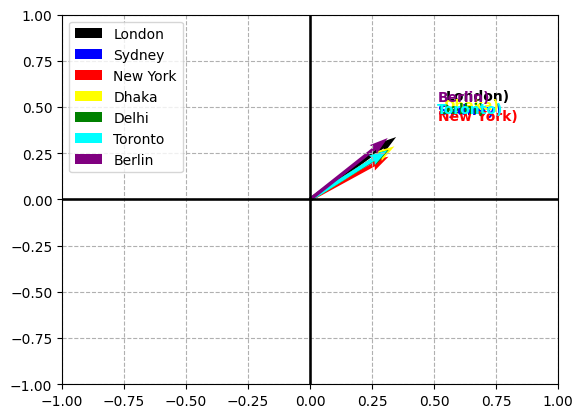

In [175]:
colores = ['black', 'blue', 'red', 'yellow', 'green', 'cyan', 'purple']
for ciudad, indice in city_dict.items():
    vector = pesos_embedding[indice]
    dibujar_vector(vector[0], vector[1], ciudad, colores[indice])

In [176]:
# Usamos la columna 'city_code' como índice para buscar en el array de pesos
# Esto crea una matriz gigante donde cada fila tiene el vector correspondiente a esa ciudad
vectores_asignados = pesos_embedding[df['city_code'].values]

# Asignamos la coordenada X e Y a nuevas columnas
df['city_emb_x'] = vectores_asignados[:, 0]
df['city_emb_y'] = vectores_asignados[:, 1]

# Verificamos
print(df[['city', 'city_emb_x', 'city_emb_y']].head())

       city  city_emb_x  city_emb_y
0    London    0.346847    0.337895
1    Sydney    0.315777    0.262963
2  New York    0.316239    0.231672
3     Dhaka    0.340180    0.287805
4     Delhi    0.317281    0.268439
